In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [2]:
#df = pd.read_csv(r"C:\Users\S\Datasets.csv")
#df = pd.read_csv("Dataset (3).csv")
df = pd.read_csv("FInal_aggregated_dataset.csv")
df = df.dropna()

In [3]:
split = int(len(df) * 0.8)
train = df.iloc[:split]
test = df.iloc[split:]

In [4]:
X_train_v = train.drop(columns=["Date","Newsenti","Tweetsenti","volatility", "garch_volatility","vol_1"], errors="ignore")
X_test_v = test.drop(columns=["Date","Newsenti","Tweetsenti","volatility", "garch_volatility","vol_1"], errors="ignore")

In [5]:
y_train_v = train["volatility"]
y_test_v = test["volatility"]

In [6]:
rf_vol = RandomForestRegressor(n_estimators=200, random_state=42)
rf_vol.fit(X_train_v, y_train_v)

RandomForestRegressor(n_estimators=200, random_state=42)

In [7]:
y_pred_vol = rf_vol.predict(X_test_v)

In [8]:
r2_vol = r2_score(y_test_v, y_pred_vol)
rmse_vol = np.sqrt(mean_squared_error(y_test_v, y_pred_vol))
mae_vol = mean_absolute_error(y_test_v, y_pred_vol)

In [9]:
print("Random Forest on Volatility")
print("R2:", r2_vol)
print("RMSE:", rmse_vol)
print("MAE:", mae_vol)

Random Forest on Volatility
R2: -0.2899113751806637
RMSE: 0.06250106937854387
MAE: 0.044807674432800024


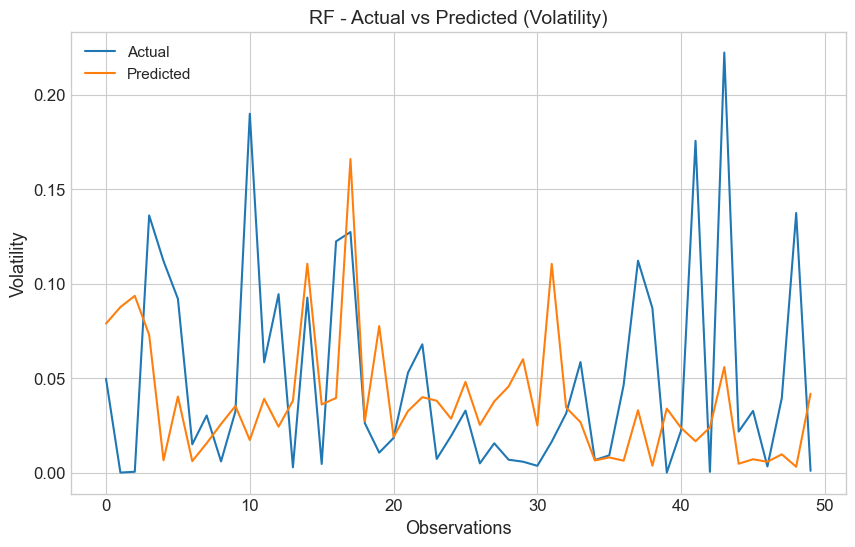

In [10]:
plt.style.use('seaborn-v0_8-whitegrid')  # clean academic look
plt.rcParams.update({"font.size": 12,"figure.figsize": (10, 6),"axes.labelsize": 13,"axes.titlesize": 14,"legend.fontsize": 11})
plt.figure()
plt.plot(y_test_v.values, label="Actual")
plt.plot(y_pred_vol, label="Predicted")
plt.title("RF - Actual vs Predicted (Volatility)")
plt.xlabel("Observations")
plt.ylabel("Volatility")
plt.legend()
plt.show()

In [11]:
X_train_g = train.drop(columns=["Date","Newsenti","Tweetsenti","garch_volatility", "volatility","vol_1"], errors="ignore")
X_test_g = test.drop(columns=["Date","Newsenti","Tweetsenti","garch_volatility", "volatility","vol_1"], errors="ignore")

In [12]:
y_train_g = train["garch_volatility"]
y_test_g = test["garch_volatility"]

In [13]:
rf_garch = RandomForestRegressor(n_estimators=200, random_state=42)
rf_garch.fit(X_train_g, y_train_g)

RandomForestRegressor(n_estimators=200, random_state=42)

In [14]:
y_pred_garch = rf_garch.predict(X_test_g)

In [15]:
r2_garch = r2_score(y_test_g, y_pred_garch)
rmse_garch = np.sqrt(mean_squared_error(y_test_g, y_pred_garch))
mae_garch = mean_absolute_error(y_test_g, y_pred_garch)

In [16]:
print(" Random Forest on GARCH Volatility ")
print("R2:", r2_garch)
print("RMSE:", rmse_garch)
print("MAE:", mae_garch)

 Random Forest on GARCH Volatility 
R2: -2.8532048252187607
RMSE: 8.15782367238346
MAE: 5.968190884024201


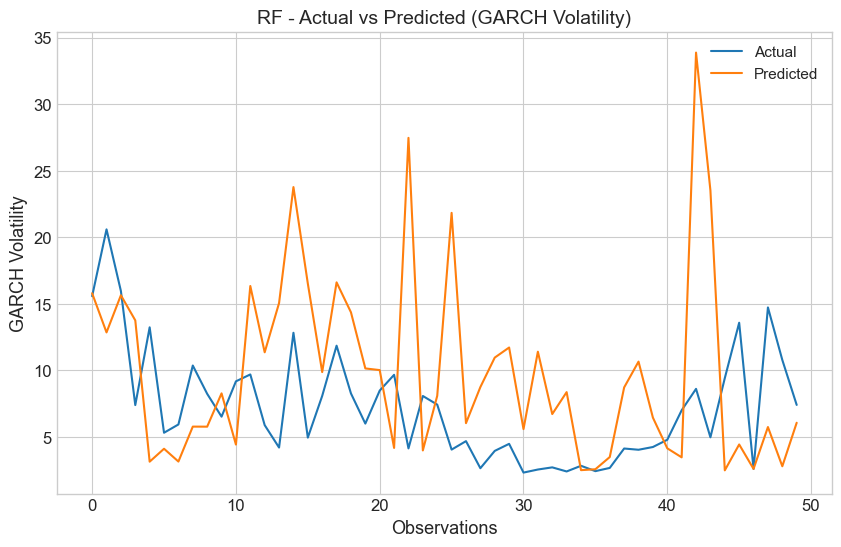

In [17]:
plt.figure()
plt.plot(y_test_g.values, label="Actual")
plt.plot(y_pred_garch, label="Predicted")
plt.title("RF - Actual vs Predicted (GARCH Volatility)")
plt.xlabel("Observations")
plt.ylabel("GARCH Volatility")
plt.legend()
plt.show()

In [19]:
df = df.sort_values(by='Date').reset_index(drop=True)
#df = df.drop(columns=['sentiment','NewsSenti'])
Y = df['volatility']
X = df.drop(columns=["Newsenti","Tweetsenti",'volatility', 'Date','garch_volatility'])

In [20]:
X['lag1'] = Y.shift(1)
X['lag2'] = Y.shift(2)
# Drop NaNs from lagging
data = pd.concat([X, Y], axis=1).dropna()
X = data.drop(columns=['volatility'])
Y = data['volatility']

In [21]:
n = len(X)
splits = [int(0.80 * n),int(0.85 * n),int(0.90 * n),int(0.95 * n)]

In [22]:
results = []

for i, split in enumerate(splits):

    X_train = X.iloc[:split]
    Y_train = Y.iloc[:split]

    X_test = X.iloc[split:]
    Y_test = Y.iloc[split:]

    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=5,
        random_state=42
    )

    model.fit(X_train, Y_train)

    preds = model.predict(X_test)

    # Metrics
    mse = mean_squared_error(Y_test, preds)
    mae = mean_absolute_error(Y_test, preds)
    r2 = r2_score(Y_test, preds)

    # Directional Accuracy
    actual_diff = Y_test.values - Y.iloc[split-1:-1].values
    pred_diff = preds - Y.iloc[split-1:-1].values

    direction_correct = np.sign(actual_diff) == np.sign(pred_diff)
    directional_accuracy = np.mean(direction_correct)

    results.append({"Split": i+1,"Train Size": split,"Test Size": len(Y_test),"MSE": mse,"MAE": mae,"R2": r2,"Directional Accuracy": directional_accuracy})
    print(f"""
    Split {i+1}
    Train Size: {split}
    Test Size: {len(Y_test)}
    MSE: {mse:.4f}
    MAE: {mae:.4f}
    R2: {r2:.4f}
    Directional Accuracy: {directional_accuracy:.4f}
    """)
results_df = pd.DataFrame(results)


    Split 1
    Train Size: 198
    Test Size: 50
    MSE: 0.0094
    MAE: 0.0488
    R2: -5.3358
    Directional Accuracy: 0.6200
    

    Split 2
    Train Size: 210
    Test Size: 38
    MSE: 0.0114
    MAE: 0.0541
    R2: -7.6892
    Directional Accuracy: 0.6053
    

    Split 3
    Train Size: 223
    Test Size: 25
    MSE: 0.0129
    MAE: 0.0472
    R2: -33.8054
    Directional Accuracy: 0.6000
    

    Split 4
    Train Size: 235
    Test Size: 13
    MSE: 0.0014
    MAE: 0.0304
    R2: -1.2504
    Directional Accuracy: 0.5385
    


In [25]:
df = df.sort_values(by='Date').reset_index(drop=True)
Y = df['garch_volatility']
X = df.drop(columns=["Date","Newsenti","Tweetsenti",'garch_volatility'])

In [26]:
X['lag1'] = Y.shift(1)
X['lag2'] = Y.shift(2)

# Drop NaNs from lagging
data = pd.concat([X, Y], axis=1).dropna()
X = data.drop(columns=['garch_volatility'])
Y = data['garch_volatility']

In [27]:
results = []

for i, split in enumerate(splits):

    X_train = X.iloc[:split]
    Y_train = Y.iloc[:split]

    X_test = X.iloc[split:]
    Y_test = Y.iloc[split:]

    model = RandomForestRegressor(
        n_estimators=100,
        max_depth=5,
        random_state=42
    )

    model.fit(X_train, Y_train)

    preds = model.predict(X_test)

    # Metrics
    mse = mean_squared_error(Y_test, preds)
    mae = mean_absolute_error(Y_test, preds)
    r2 = r2_score(Y_test, preds)

    # Directional Accuracy
    actual_diff = Y_test.values - Y.iloc[split-1:-1].values
    pred_diff = preds - Y.iloc[split-1:-1].values

    direction_correct = np.sign(actual_diff) == np.sign(pred_diff)
    directional_accuracy = np.mean(direction_correct)

    results.append({"Split": i+1,"Train Size": split,"Test Size": len(Y_test),"MSE": mse,"MAE": mae,"R2": r2,"Directional Accuracy": directional_accuracy})
    print(f"""
    Split {i+1}
    Train Size: {split}
    Test Size: {len(Y_test)}
    MSE: {mse:.4f}
    MAE: {mae:.4f}
    R2: {r2:.4f}
    Directional Accuracy: {directional_accuracy:.4f}
    """)
results_df = pd.DataFrame(results)


    Split 1
    Train Size: 198
    Test Size: 50
    MSE: 15.6445
    MAE: 2.6168
    R2: -0.6743
    Directional Accuracy: 0.6600
    

    Split 2
    Train Size: 210
    Test Size: 38
    MSE: 12.7147
    MAE: 2.3943
    R2: -0.3783
    Directional Accuracy: 0.6579
    

    Split 3
    Train Size: 223
    Test Size: 25
    MSE: 6.9948
    MAE: 1.9610
    R2: -0.0173
    Directional Accuracy: 0.6000
    

    Split 4
    Train Size: 235
    Test Size: 13
    MSE: 9.8480
    MAE: 2.4129
    R2: -11.6915
    Directional Accuracy: 0.4615
    


In [29]:
results_df = pd.DataFrame(results)

print(results_df)

   Split  Train Size  Test Size        MSE       MAE         R2  \
0      1         198         50  15.644542  2.616819  -0.674350   
1      2         210         38  12.714718  2.394270  -0.378349   
2      3         223         25   6.994844  1.960974  -0.017263   
3      4         235         13   9.848049  2.412867 -11.691475   

   Directional Accuracy  
0              0.660000  
1              0.657895  
2              0.600000  
3              0.461538  
